In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np 
from scipy import stats
import torch
import json
from src.models.test import play_game_test
from stockfish import Stockfish
import sys 
sys.path.append('C:/Users/isaac/Desktop/c-gpt/')
from config import model_params, device, DATA_DIR, test_config
from src.models.model_base import GPT 


In [56]:
knight_df = (
    pd.read_csv('knight.csv')
    .groupby(by = ['step'], as_index=False)
    [['illegal_rate', 'illegal_moves', 'game_length', 'train_loss', 'val_loss']]
    .agg(['mean', 'var', 'count'])
)
knight_df.columns = [x +"_" +y for x,y in knight_df.columns.values]

knight_df['illegal_rate_CI'] = (
    stats.t.ppf(
        (1 + 0.95) / 2, 
        knight_df['illegal_rate_count']-1
    ) *
    np.sqrt(knight_df['illegal_rate_var'] / knight_df['illegal_rate_count'])
)

<Axes: xlabel='step_', ylabel='val_loss_mean'>

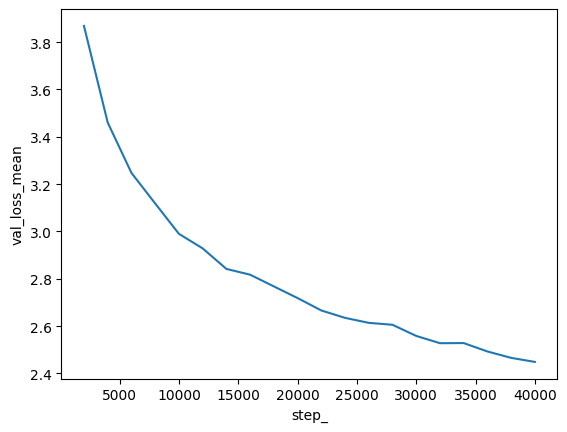

In [33]:
sns.lineplot(knight_df, x = 'step_', y = 'val_loss_mean')

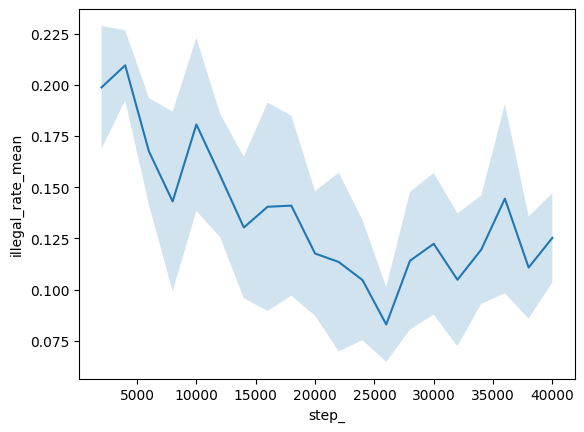

In [57]:
sns.lineplot(knight_df, x='step_', y='illegal_rate_mean')
plt.fill_between(
    knight_df['step_'],
    knight_df['illegal_rate_mean'] - knight_df['illegal_rate_CI'],
    knight_df['illegal_rate_mean'] + knight_df['illegal_rate_CI'],
    alpha=0.2
)

In [ ]:
# ----- Check our vocab length 
with open(DATA_DIR / 'processed' / 'itos.json', 'r') as file:
    itos = json.load(file)
itos = {int(i) : ch for i,ch in itos.items()} 
with open(DATA_DIR / 'processed' / 'stoi.json', 'r') as file:
    stoi = json.load(file)

vocab_size = len(itos)


model = GPT(
        vocab_size=vocab_size,
        n_embd=model_params.n_embd,
        n_head=model_params.n_head,
        n_layer=model_params.n_layer,
        block_size=model_params.block_size,
        dropout=model_params.dropout,
        device=device,
    ).to(device)

checkpoint = torch.load('checkpoint_40000.pt', map_location=device)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()

stockfish = Stockfish(path= test_config.stockfish_path)

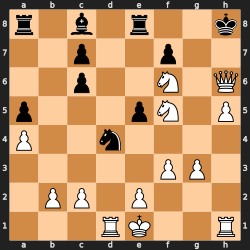

{'illegal_moves': 1,
 'illegal_rate': 0.018867924528301886,
 'stock_lvl': 3,
 'winner': 'stock',
 'game_length': 53}

In [72]:
play_game_test(stock_lvl=3, display_game=True, stockfish=stockfish, model=model)